In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [69]:
df=pd.read_csv(r'E:\Imarticus BNGLR\FMCG Sales Forecsting 24-25\Dataset.csv')

In [70]:
df.head()

,Order_ID,Order_Date,Delivery_Date,Expected_Delivery,Delivery_Status,Payment_Mode,Payment_Status,Month_Name,Month_Number,Quarter,...,Quantity,Discount_Pct,Unit_Selling_Price,Gross_Value,Net_Sales_Value,Margin_Value,Target_Value,Is_Return,Gross_Margin_Pct,Achievement_Pct
0,ORD000525,2024-01-01,2024-01-06,2024-01-04,Delivered,UPI,Paid,January,1,Q1,...,32.4,2.8,94.71,3157.06,3068.60,709.88,3434.72,No,23.1,89.3
1,ORD000286,2024-01-01,2024-01-04,2024-01-05,Delivered,Credit,Paid,January,1,Q1,...,57.8,5.9,49.12,3017.16,2839.14,584.94,2862.87,No,20.6,99.2
2,ORD000310,2024-01-01,2024-01-06,2024-01-04,Delivered,UPI,Paid,January,1,Q1,...,19.0,0.8,163.98,3140.70,3115.62,769.12,3146.96,No,24.7,99.0
3,ORD000741,2024-01-01,2024-01-05,2024-01-04,Delivered,Cash,Overdue,January,1,Q1,...,15.0,3.7,65.35,1017.90,980.25,219.75,1071.61,No,22.4,91.5
4,ORD000605,2024-01-01,NaN,2024-01-05,Cancelled,Credit,Refunded,January,1,Q1,...,167.4,3.2,69.06,11942.32,11560.64,2638.22,12400.45,No,22.8,93.2


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20366 entries, 0 to 20365
Data columns (total 48 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            20366 non-null  str    
 1   Order_Date          20366 non-null  str    
 2   Delivery_Date       13695 non-null  str    
 3   Expected_Delivery   20366 non-null  str    
 4   Delivery_Status     20366 non-null  str    
 5   Payment_Mode        20366 non-null  str    
 6   Payment_Status      20366 non-null  str    
 7   Month_Name          20366 non-null  str    
 8   Month_Number        20366 non-null  int64  
 9   Quarter             20366 non-null  str    
 10  Year                20366 non-null  int64  
 11  Calendar_YearMonth  20366 non-null  str    
 12  Distributor_Code    20366 non-null  str    
 13  Distributor_Name    20366 non-null  str    
 14  City                20366 non-null  str    
 15  Zone                20366 non-null  str    
 16  Tier           

In [72]:
df.isnull().sum()

Order_ID                 0
Order_Date               0
Delivery_Date         6671
Expected_Delivery        0
Delivery_Status          0
Payment_Mode             0
Payment_Status           0
Month_Name               0
Month_Number             0
Quarter                  0
Year                     0
Calendar_YearMonth       0
Distributor_Code         0
Distributor_Name         0
City                     0
Zone                     0
Tier                     0
Owner_Name               0
Phone                    0
GST_Number               0
Credit_Limit             0
Years_Active             0
DS_ID                    0
DS_Name                  0
DS_Type                  0
Beat_Name                0
Beat_Key                 0
Outlet_Name              0
Outlet_Type              0
Channel_Type             0
SKU_Code                 0
SKU_Name                 0
Sub_Category             0
Category                 0
SBU                      0
MRP                      0
Cost_Price               0
D

In [73]:
df['Delivery_Status'].value_counts()

Delivery_Status
Delivered     14381
Pending        2025
Cancelled      1980
In Transit     1980
Name: count, dtype: int64

In [74]:
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

df['Delivery_Days'] = (df['Delivery_Date'] - df['Order_Date']).dt.days

In [75]:
delivered_df = df[df['Delivery_Status'] == 'Delivered']

In [76]:
delivered_df['Delivery_Days'].mean()

np.float64(3.49390288426433)

In [77]:
df.columns.tolist()

['Order_ID',
 'Order_Date',
 'Delivery_Date',
 'Expected_Delivery',
 'Delivery_Status',
 'Payment_Mode',
 'Payment_Status',
 'Month_Name',
 'Month_Number',
 'Quarter',
 'Year',
 'Calendar_YearMonth',
 'Distributor_Code',
 'Distributor_Name',
 'City',
 'Zone',
 'Tier',
 'Owner_Name',
 'Phone',
 'GST_Number',
 'Credit_Limit',
 'Years_Active',
 'DS_ID',
 'DS_Name',
 'DS_Type',
 'Beat_Name',
 'Beat_Key',
 'Outlet_Name',
 'Outlet_Type',
 'Channel_Type',
 'SKU_Code',
 'SKU_Name',
 'Sub_Category',
 'Category',
 'SBU',
 'MRP',
 'Cost_Price',
 'Distributor_Price',
 'Quantity',
 'Discount_Pct',
 'Unit_Selling_Price',
 'Gross_Value',
 'Net_Sales_Value',
 'Margin_Value',
 'Target_Value',
 'Is_Return',
 'Gross_Margin_Pct',
 'Achievement_Pct',
 'Delivery_Days']

In [78]:
#Total Net Sales Value
df['Net_Sales_Value'].sum()

np.float64(107333620.31)

In [79]:
#Average Net Sales Value
df['Net_Sales_Value'].mean()

np.float64(5270.235702150643)

In [80]:
df['Net_Sales_Value'].describe()


count    20366.000000
mean      5270.235702
std       7566.258851
min     -17439.230000
25%       1005.092500
50%       2501.355000
75%       6298.862500
max      52946.190000
Name: Net_Sales_Value, dtype: float64

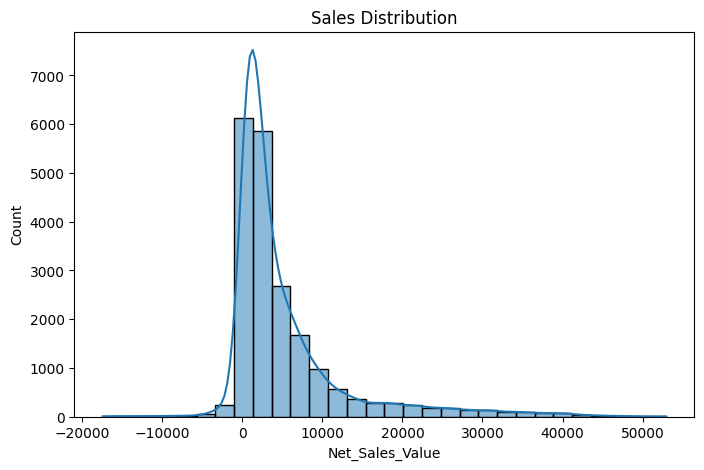

In [81]:
#Sales Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Net_Sales_Value'], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()

In [82]:
#Year on Year Sales
df.groupby('Year')['Net_Sales_Value'].sum()

Year
2024    52176228.22
2025    55157392.09
Name: Net_Sales_Value, dtype: float64

In [83]:
yearly_sales = df.groupby('Year')['Net_Sales_Value'].sum()

yearly_percentage = (yearly_sales / yearly_sales.sum()) * 100

print(yearly_percentage)

Year
2024    48.611263
2025    51.388737
Name: Net_Sales_Value, dtype: float64


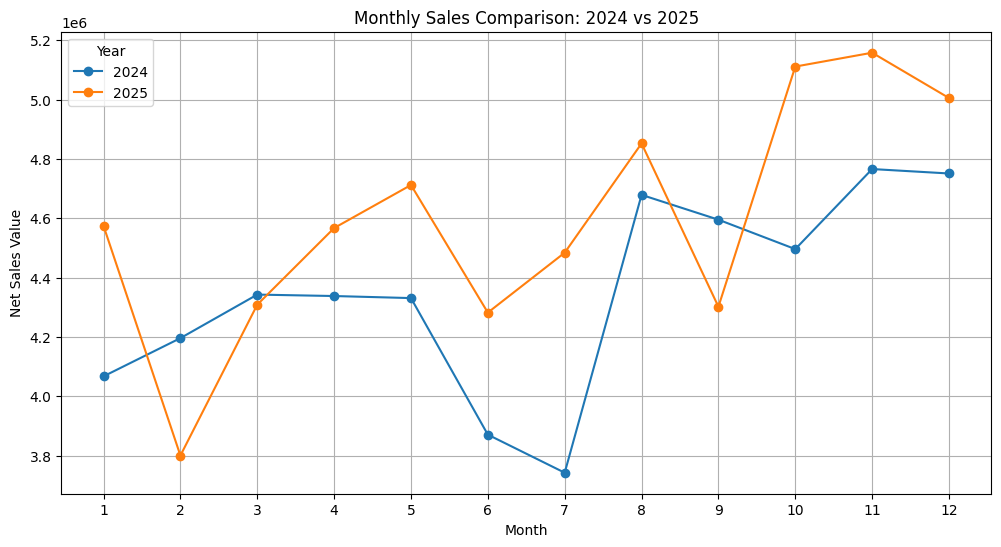

In [98]:
#Monthly Sales
monthly_sales = (
    df.groupby(['Year', 'Month_Number'])['Net_Sales_Value']
      .sum()
      .reset_index()
)

pivot_sales = monthly_sales.pivot(
    index='Month_Number',
    columns='Year',
    values='Net_Sales_Value'
)

pivot_sales.plot(
    figsize=(12,6),
    marker='o'
)

plt.title('Monthly Sales Comparison: 2024 vs 2025')
plt.xlabel('Month')
plt.ylabel('Net Sales Value')
plt.xticks(range(1,13))
plt.grid(True)
plt.legend(title='Year')
plt.show()

In [85]:
#Quater Sales
df.groupby('Quarter')['Net_Sales_Value'].sum()

Quarter
Q1    25290158.44
Q2    26101421.58
Q3    26654959.34
Q4    29287080.95
Name: Net_Sales_Value, dtype: float64

<Axes: xlabel='Quarter'>

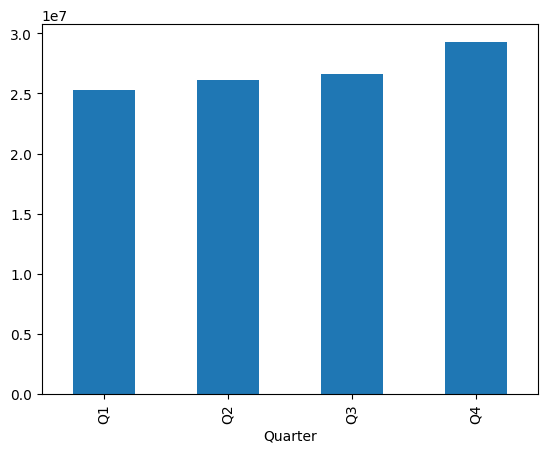

In [86]:
df.groupby('Quarter')['Net_Sales_Value'].sum().plot(kind='bar')

In [88]:
dist_sales = df.groupby('Distributor_Name')['Net_Sales_Value'].sum().sort_values(ascending=False)

In [89]:
#contribution of top distributors to total sales
top_20_percent = int(len(dist_sales) * 0.2)

top_distributors = dist_sales.head(top_20_percent)
top_distributors.sum() / dist_sales.sum() * 100

np.float64(25.76138332065919)

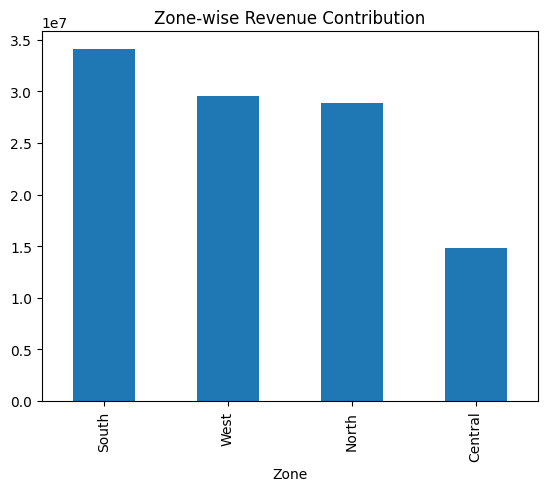

In [90]:
#Zone wise Sales
zone_sales = df.groupby('Zone')['Net_Sales_Value'].sum().sort_values(ascending=False)

zone_sales.plot(kind='bar')
plt.title("Zone-wise Revenue Contribution")
plt.show()

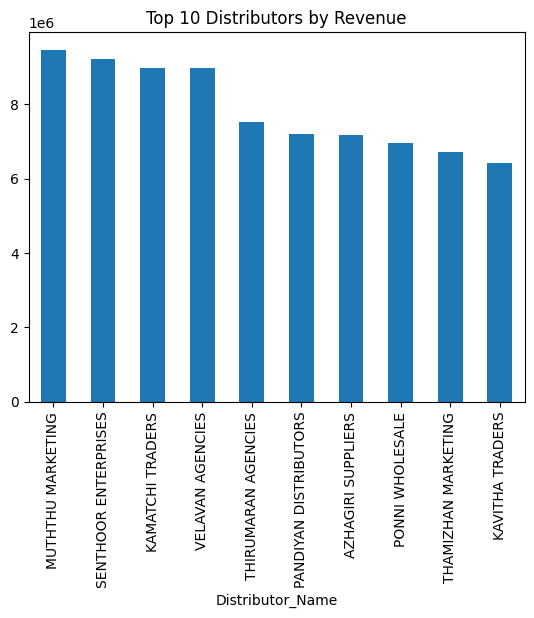

In [91]:
#Top 10 Distributors by Revenue
dist_sales = df.groupby('Distributor_Name')['Net_Sales_Value'].sum().sort_values(ascending=False).head(10)

dist_sales.plot(kind='bar')
plt.title("Top 10 Distributors by Revenue")
plt.show()

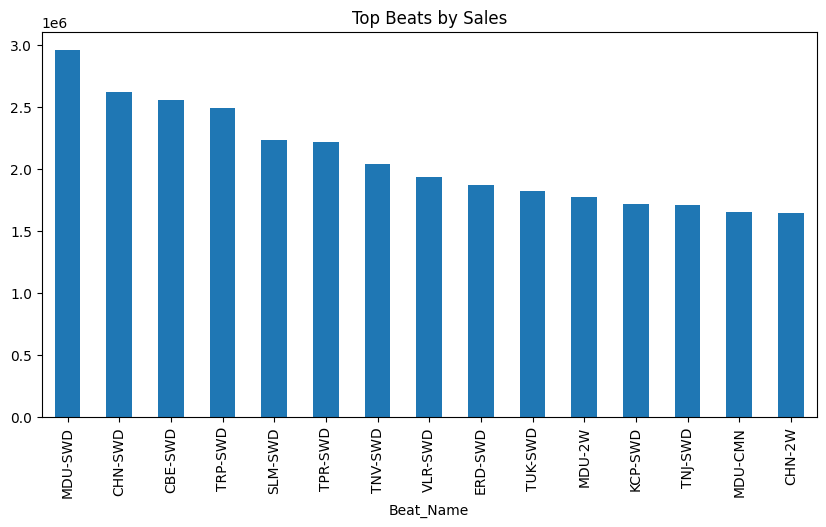

In [92]:
#Beat Sales
beat_sales = (
    df.groupby('Beat_Name')['Net_Sales_Value']
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

beat_sales.plot(kind='bar', figsize=(10,5))
plt.title("Top Beats by Sales")
plt.show()

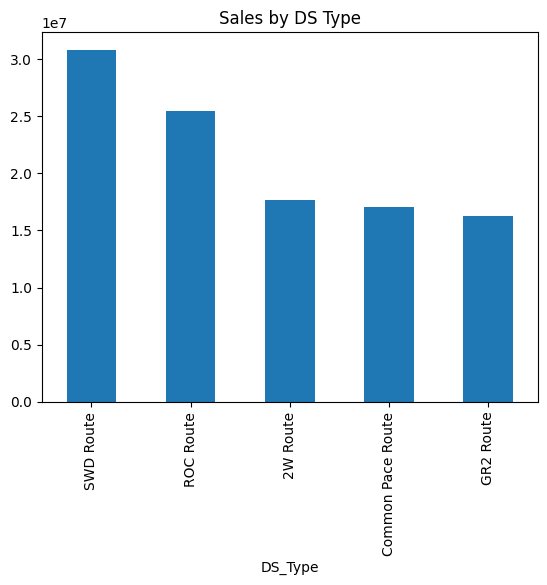

In [93]:
ds_sales = (
    df.groupby('DS_Type')['Net_Sales_Value']
      .sum()
      .sort_values(ascending=False)
)

ds_sales.plot(kind='bar')
plt.title("Sales by DS Type")
plt.show()

In [94]:
distributor = 'KAMATCHI TRADERS'

(
    df[df['Distributor_Name'] == distributor]
    .groupby(['DS_Type', 'Beat_Name'])['Net_Sales_Value']
    .sum()
    .reset_index()
    .sort_values('Net_Sales_Value', ascending=False)
)

,DS_Type,Beat_Name,Net_Sales_Value
5,SWD Route,CBE-SWD,2559279.34
0,2W Route,CBE-2W,1615473.02
1,Common Pace Route,CBE-CMN,1518910.19
2,GR2 Route,CBE-GR2,1361857.79
4,ROC Route,CBE-ROC-B,1013876.64
3,ROC Route,CBE-ROC-A,907328.74


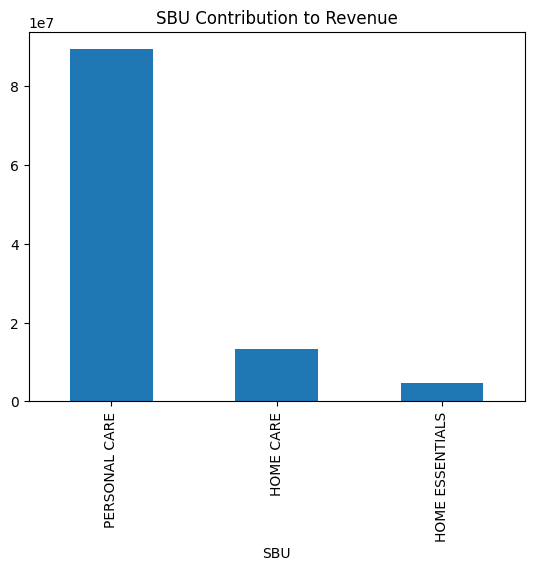

In [99]:
#SBU analysis
sbu_sales = df.groupby('SBU')['Net_Sales_Value'].sum().sort_values(ascending=False)

sbu_sales.plot(kind='bar')
plt.title("SBU Contribution to Revenue")
plt.show()

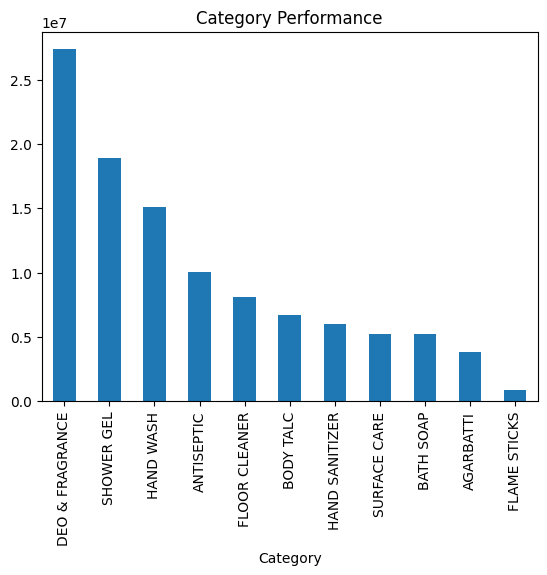

In [101]:
#Category Analysis
category_sales = df.groupby('Category')['Net_Sales_Value'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar')
plt.title("Category Performance")
plt.show()

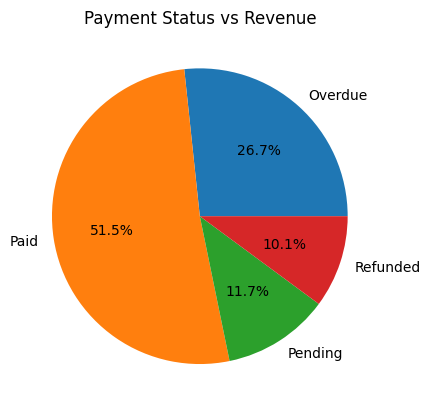

In [103]:
#Payment Risk Analysis
payment_sales = df.groupby('Payment_Status')['Net_Sales_Value'].sum()

payment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Status vs Revenue")
plt.show()

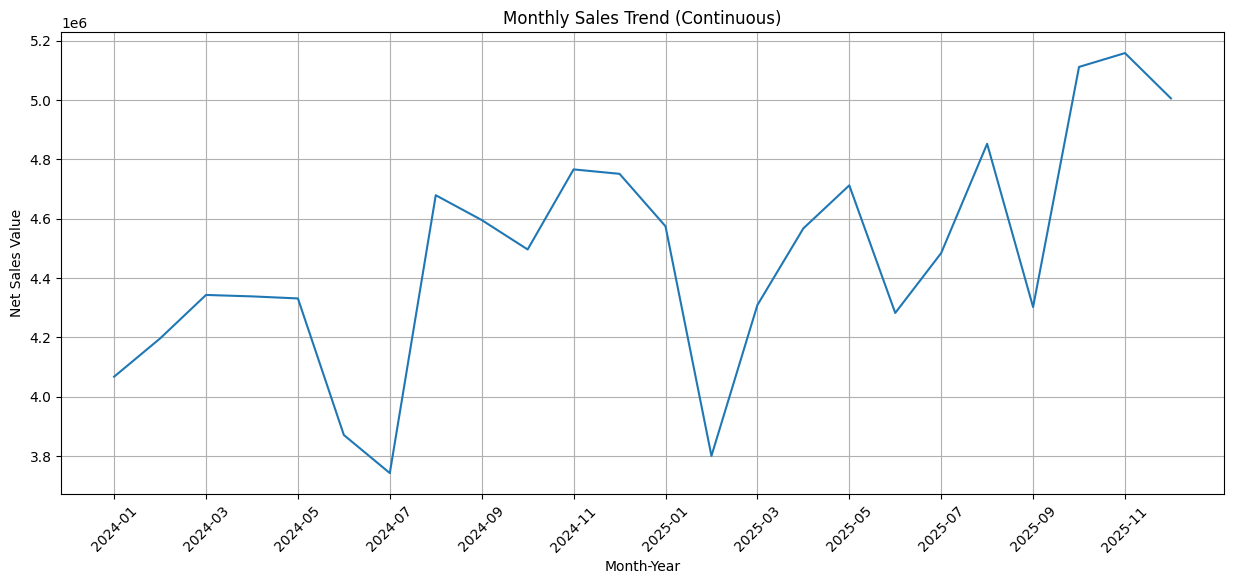

In [105]:
#Seasonality Trend
monthly_trend = df.groupby('Calendar_YearMonth')['Net_Sales_Value'].sum()

plt.figure(figsize=(15,6))
plt.plot(monthly_trend.index, monthly_trend.values)

plt.xticks(monthly_trend.index[::2], rotation=45)  # show every 2nd month
plt.title("Monthly Sales Trend (Continuous)")
plt.xlabel("Month-Year")
plt.ylabel("Net Sales Value")

plt.grid(True)
plt.show()

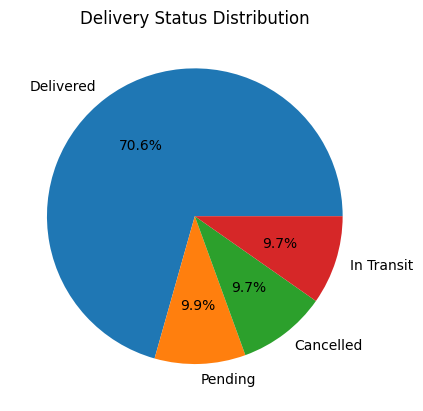

In [106]:
#Delivery Intelligence
df['Delivery_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Delivery Status Distribution")
plt.show()

In [107]:
df.groupby('Delivery_Status')['Net_Sales_Value'].sum()

Delivery_Status
Cancelled     10853164.11
Delivered     74263692.90
In Transit    11012048.97
Pending       11204714.33
Name: Net_Sales_Value, dtype: float64

24